In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [2]:
df = pd.read_csv('./Dataset A/2A.tsv', delimiter='\t')
df.head()

,Customer ID,Birth Date,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,1969/03/05,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,2005/07/01,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,1974/12/01,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,2003/11/21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,1979/09/13,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


## Check Unique Values

In [3]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(col, df[col].unique())
        print()

Birth Date ['1969/03/05' '2005/07/01' '1974/12/01' ... '1972/02/11' '1978/05/02'
 '1980/03/30']

Gender ['Male' 'M' 'Female' 'f']

Item Purchased ['Blouse' 'Sweater' 'Jeans' 'Sandals' 'Sneakers' 'Shirt' 'Shorts' 'Coat'
 'Handbag' 'Shoes' 'Dress' 'Skirt' 'Sunglasses' 'Pants' 'Jacket' 'Hoodie'
 'Jewelry' 'T-shirt' 'Scarf' 'Hat' 'Socks' 'Backpack' 'Belt' 'Boots'
 'Gloves']

Category ['Clothing' 'Footwear' 'Outerwear' 'Accessories']

Location ['Kentucky' 'Maine' 'Massachusetts' 'Rhode Island' 'Oregon' 'Wyoming'
 'Montana' 'Louisiana' 'West Virginia' 'Missouri' 'Arkansas' 'Hawaii'
 'Delaware' 'New Hampshire' 'New York' 'Alabama' 'Mississippi'
 'North Carolina' 'California' 'Oklahoma' 'Florida' 'Texas' 'Nevada'
 'Kansas' 'Colorado' 'North Dakota' 'Illinois' 'Indiana' 'Arizona'
 'Alaska' 'Tennessee' 'Ohio' 'New Jersey' 'Maryland' 'Vermont'
 'New Mexico' 'South Carolina' 'Idaho' 'Pennsylvania' 'Connecticut' 'Utah'
 'Virginia' 'Georgia' 'Nebraska' 'Iowa' 'South Dakota' 'Minnesota'
 'Washington'

## Preprocess Data for EDA

### Remove Unnecessary Columns
- ID : Unnessary because it is unique for each row

In [4]:
df = df.drop(['Customer ID'], axis=1)

### Fix Typo
- 'Male' -> 'M'
- 'Female' -> 'F'

In [5]:
# Replace Male with M and Female with F in Gender
df['Gender'] = df['Gender'].replace('Male', 'M')
df['Gender'] = df['Gender'].replace('Female', 'F')
df['Gender'] = df['Gender'].replace('f', 'F')

### Only get birth year

In [6]:
df['Birth Date'] = pd.to_datetime(df['Birth Date'])
df['Birth_Year'] = df['Birth Date'].dt.year

df = df.drop(['Birth Date'], axis=1)

# EDA

## Missing Value

In [7]:
print(df.isnull().sum())

Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
Birth_Year                  0
dtype: int64


## Data Distribution

In [8]:
Categorical = []
Numerical = []

for col in df.columns:
    if df[col].dtype == 'object':
        Categorical.append(col)
    else:
        Numerical.append(col)
        

### Numerical Data

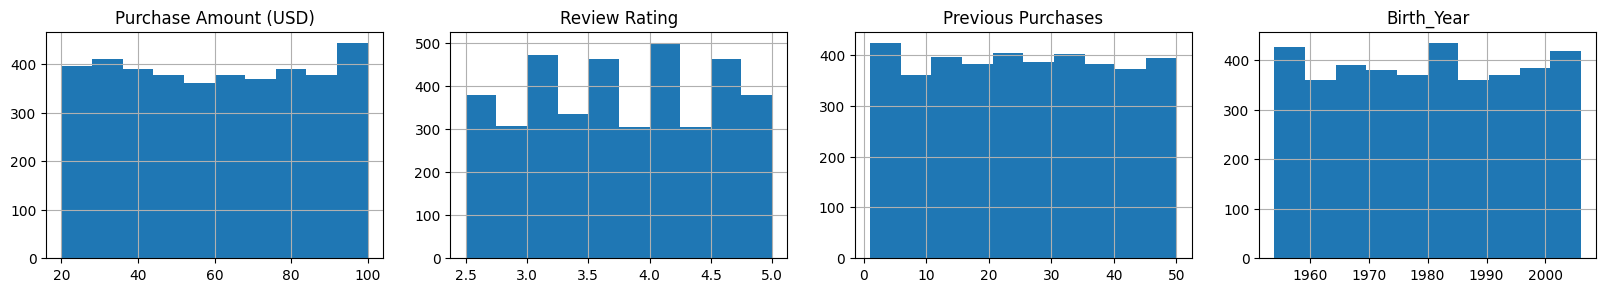

In [9]:
plt.figure(figsize=(20, 10))
for i, col in enumerate(Numerical, 1):
    plt.subplot(3, 4, i)
    df[col].hist()
    plt.title(col)

From the Distribution, all of the numerical features is evenly distributed.

### Categorical Data

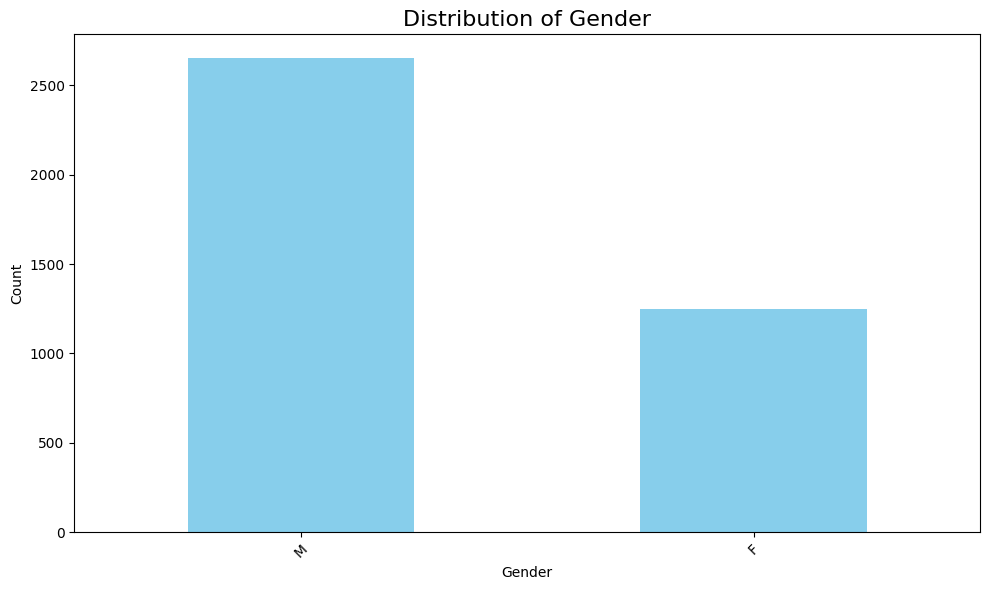

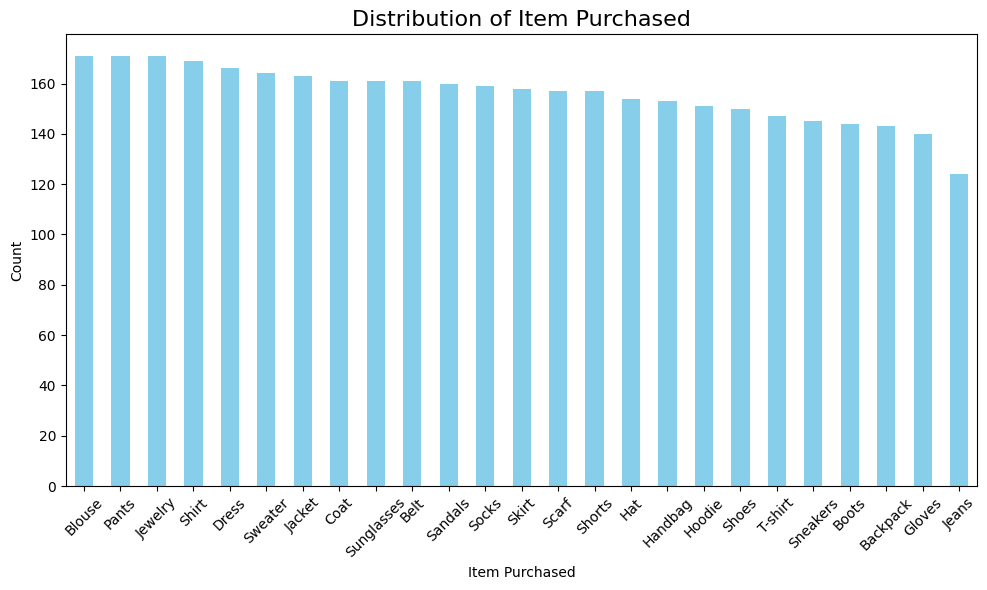

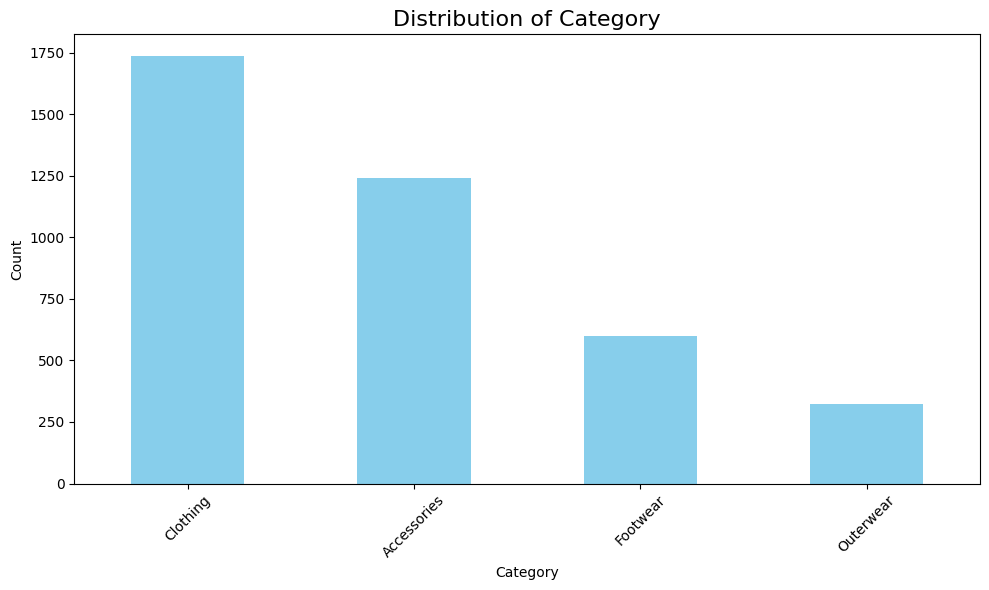

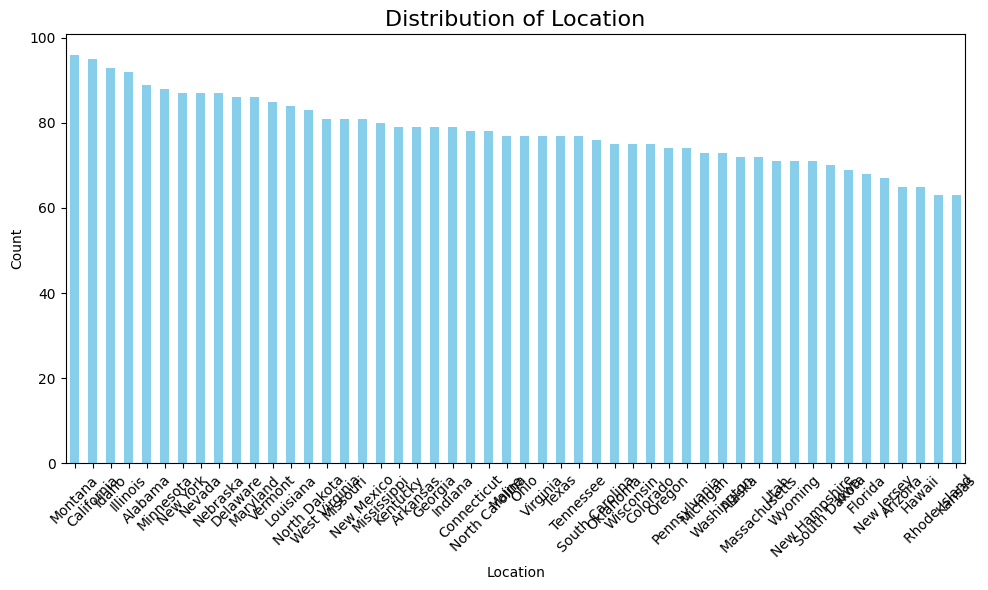

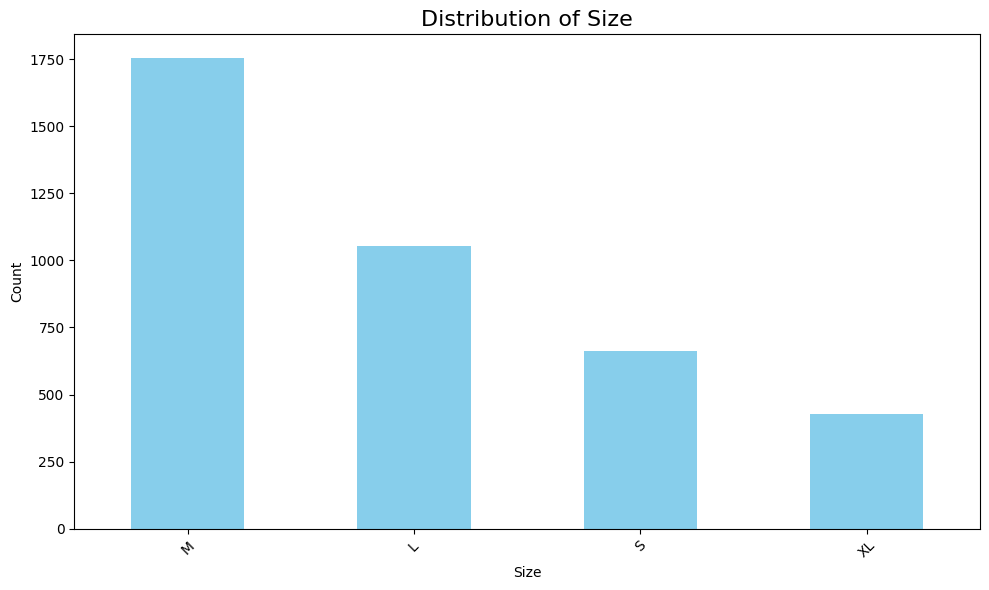

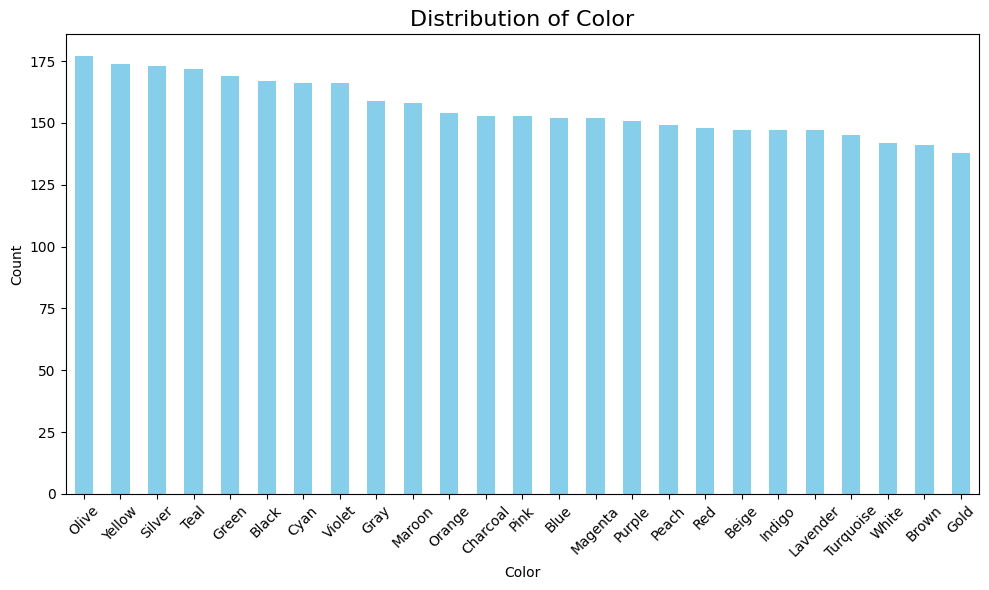

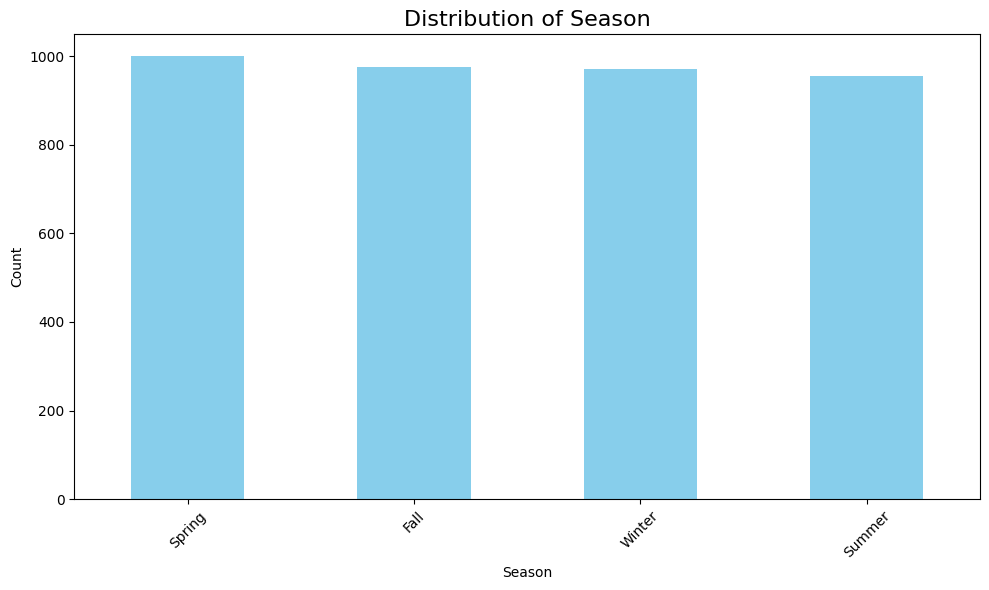

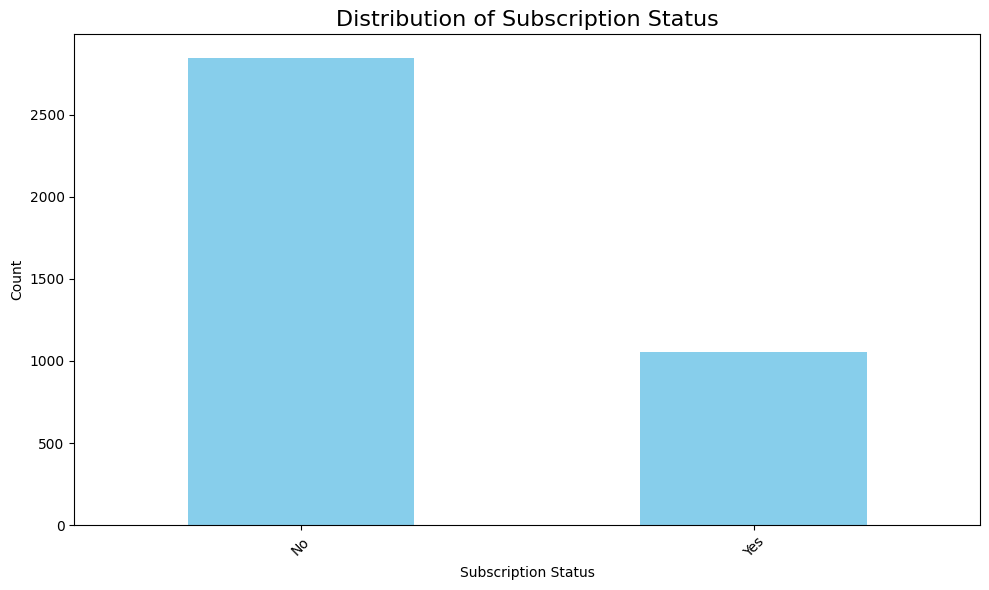

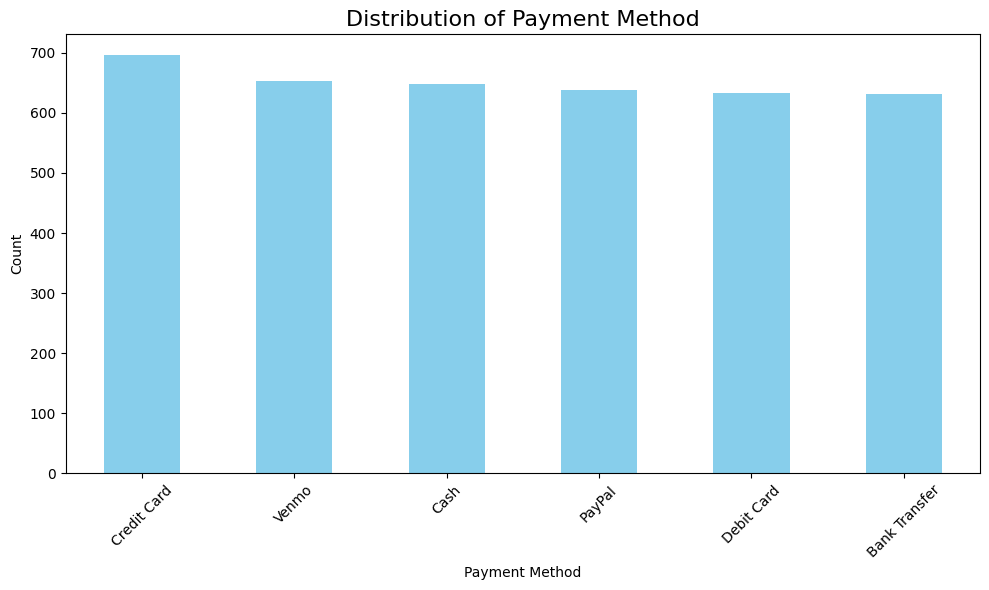

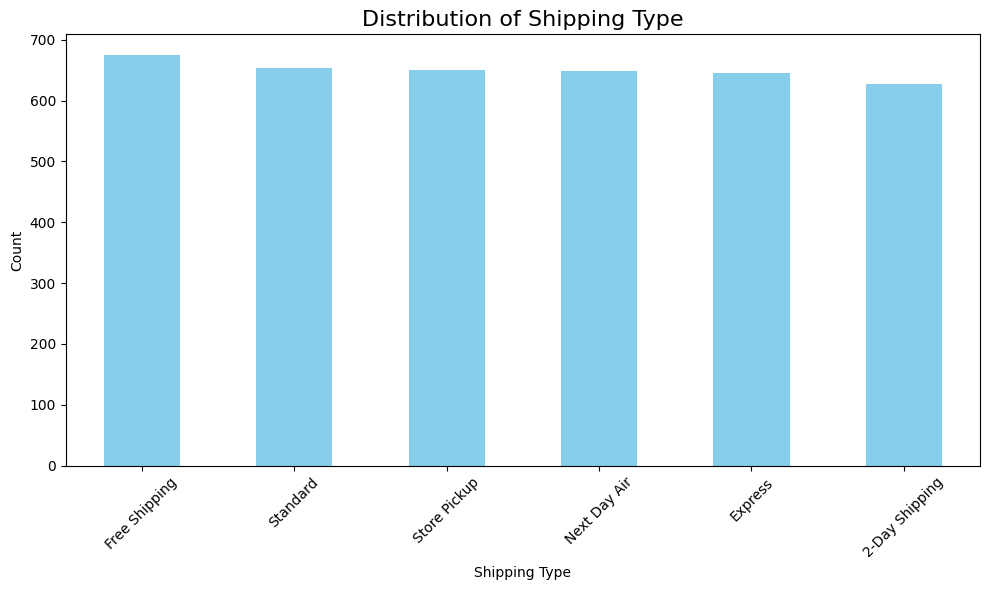

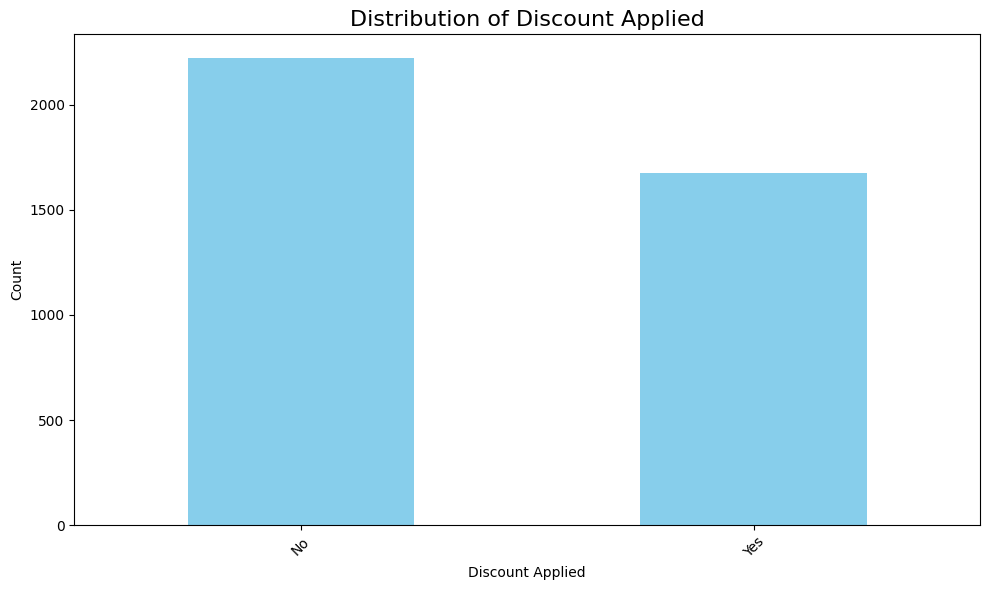

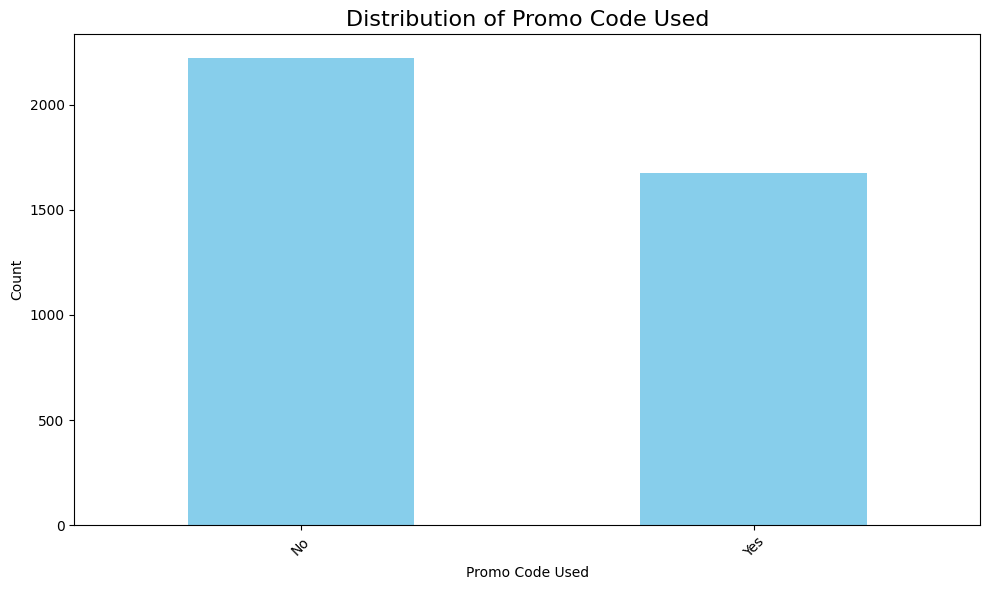

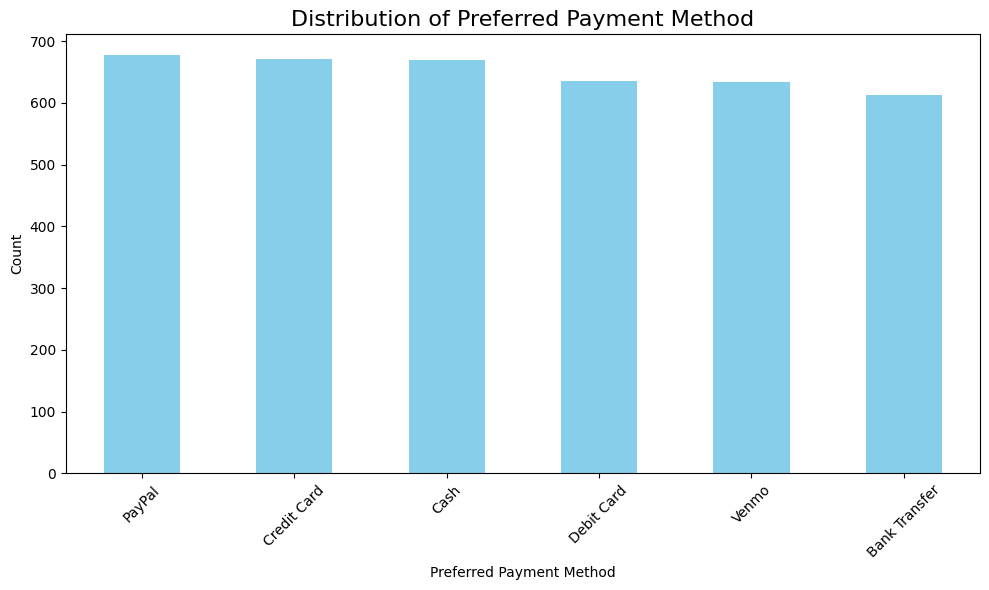

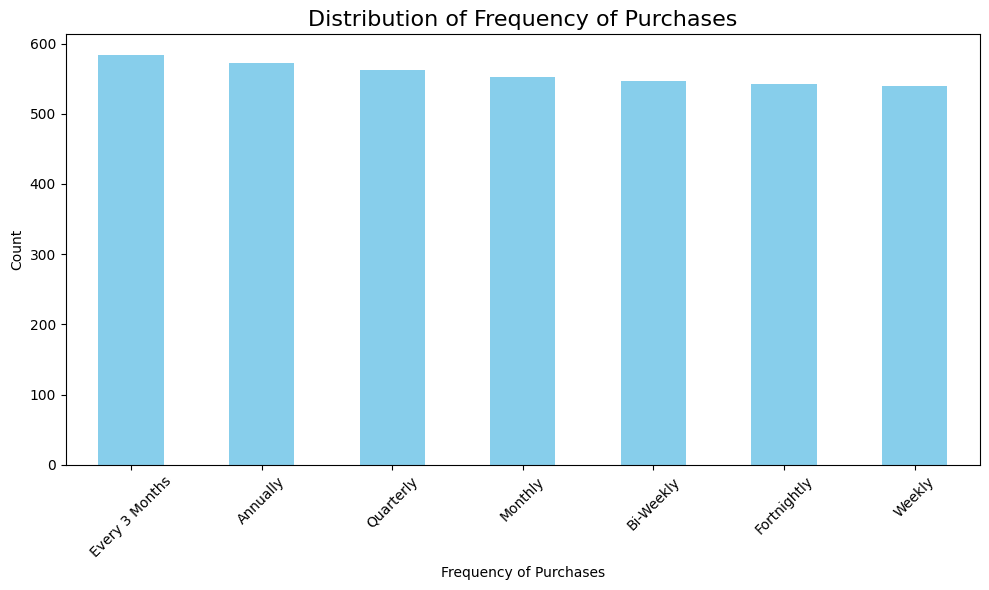

In [10]:
for column in Categorical:
    plt.figure(figsize=(10, 6))
    df[column].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f"Distribution of {column}", fontsize=16)
    plt.ylabel('Count')
    plt.xlabel(column)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

All of the categorical features is evenly distributed, with some underrepresentation but not severe.

## Correlation Check

### Numerical Data

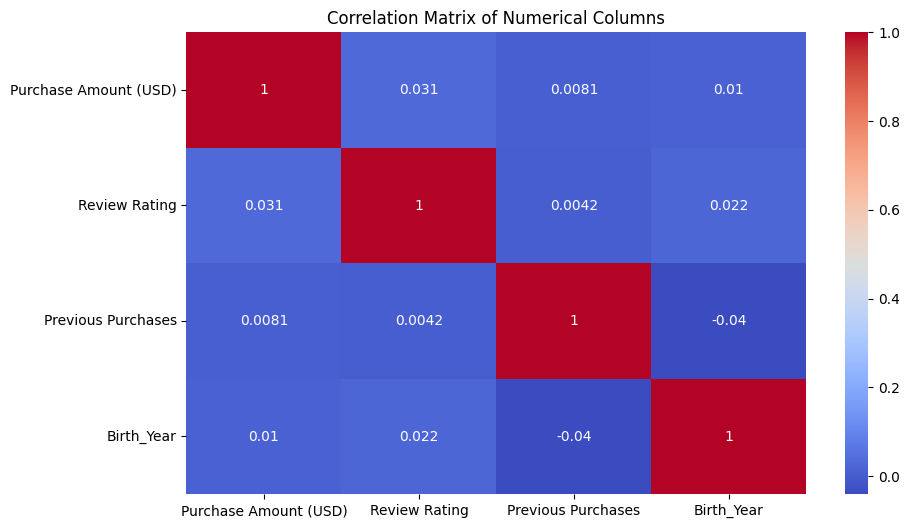

In [11]:
# Create a Heatmap of Numerical Columns
numerical_df = df[Numerical]
correlation = numerical_df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Columns')
plt.show()

From the correlation check, there is no strong correlation between features.

# Feature Engineering

## Feature Encoding

In [12]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
encoded_features = encoder.fit_transform(df[Categorical]).toarray()
encoded_feature_names = encoder.get_feature_names_out(Categorical)

encoded_df = pd.DataFrame(encoded_features, columns=encoded_feature_names)

encoded_df = pd.concat([df, encoded_df], axis=1)
encoded_df = encoded_df.drop(Categorical, axis=1)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(encoded_df)
scaled_df = pd.DataFrame(scaled_features, columns=encoded_df.columns)

# Clustering

## K-Means

### Searching for the best number of clusters

#### Elbow Method

/home/webe/Documents/University/Coding-Webe-Kuliah/Personal/Bukan-Tugas-Aing/Lauren/JKian/2702252872/.conda/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1408: RuntimeWarning:

algorithm='elkan' doesn't make sense for a single cluster. Using 'lloyd' instead.



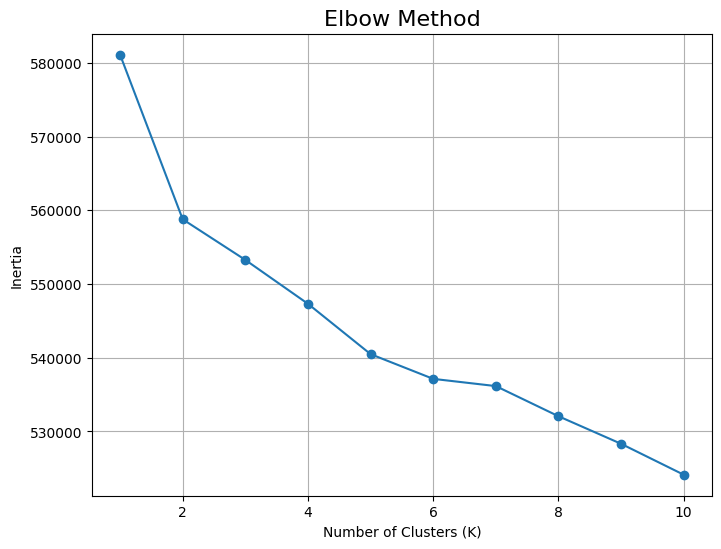

In [47]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, algorithm='elkan', max_iter=300)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)
    
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method", fontsize=16)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid()
plt.show()

#### Silhouette Score

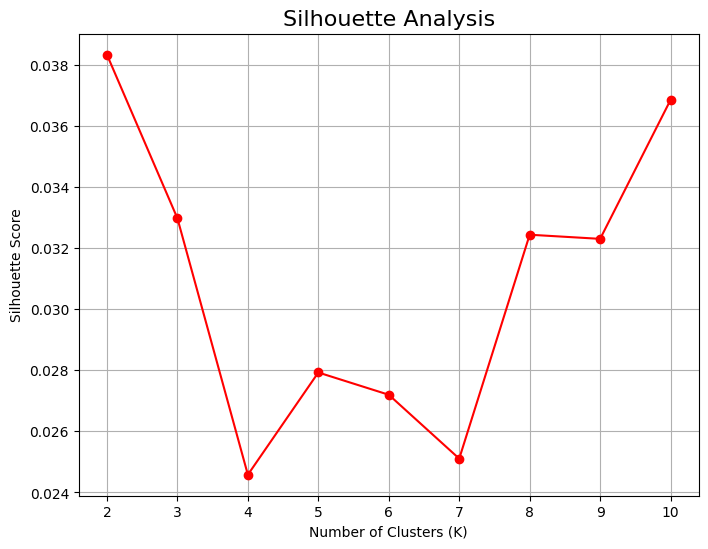

In [48]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, algorithm='elkan', max_iter=300)
    kmeans.fit(scaled_features)
    silhouette_scores.append(silhouette_score(scaled_features, kmeans.labels_))

# Plot Silhouette Scores
plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='red')
plt.title("Silhouette Analysis", fontsize=16)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()


Best = 2 clusters

### K-Means with 2 clusters

In [49]:
# Fine Tuning the KMeans Algorithm

optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42, algorithm='elkan', max_iter=300)
clusters = kmeans.fit_predict(scaled_features)

# 1c. Visualizing clusters

## K-Means

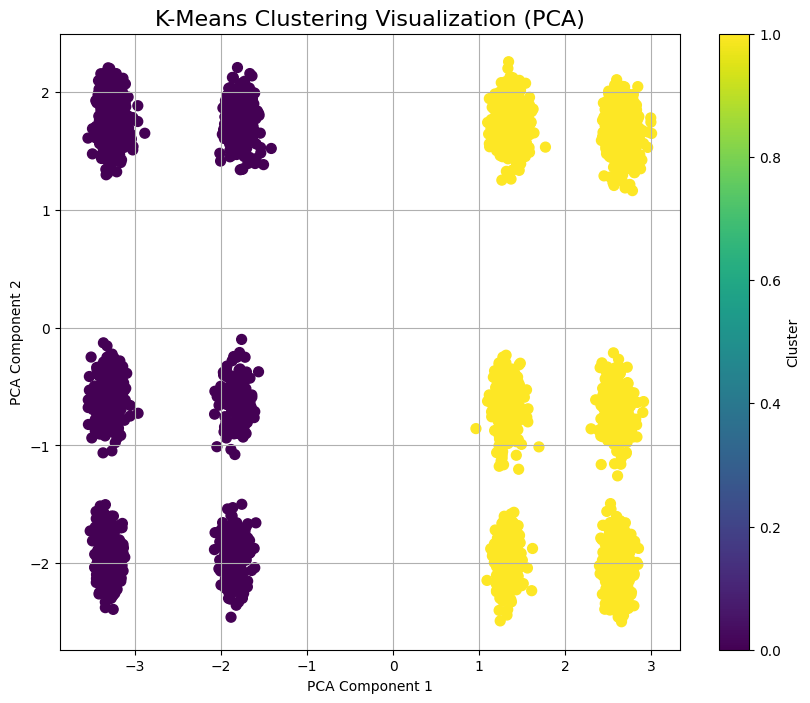

In [50]:
from sklearn.decomposition import PCA

df['Cluster'] = clusters

# Step 5: Visualize clusters using PCA (reduce to 2D)
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(scaled_features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=clusters, cmap='viridis', s=50)
plt.colorbar(scatter, label="Cluster")
plt.title("K-Means Clustering Visualization (PCA)", fontsize=16)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid()
plt.show()

Cluster Characteristics Summary:
        Gender Frequency of Purchases Item Purchased  Season  \
Cluster                                                        
0            M         Every 3 Months          Pants  Spring   
1            F               Annually         Blouse    Fall   

        Subscription Status Payment Method  Shipping Type  
Cluster                                                    
0                       Yes    Credit Card   Next Day Air  
1                        No    Credit Card  Free Shipping  

Numerical Feature Summary:
         Purchase Amount (USD)  Review Rating  Previous Purchases   Birth_Year
Cluster                                                                       
0                    59.279070       3.739654           25.742993  1979.855098
1                    60.130454       3.757715           25.056230  1979.989204


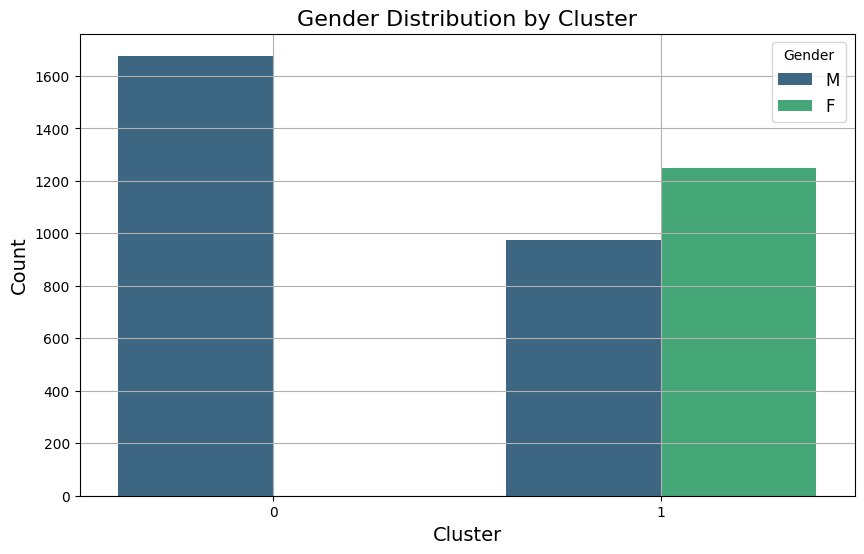

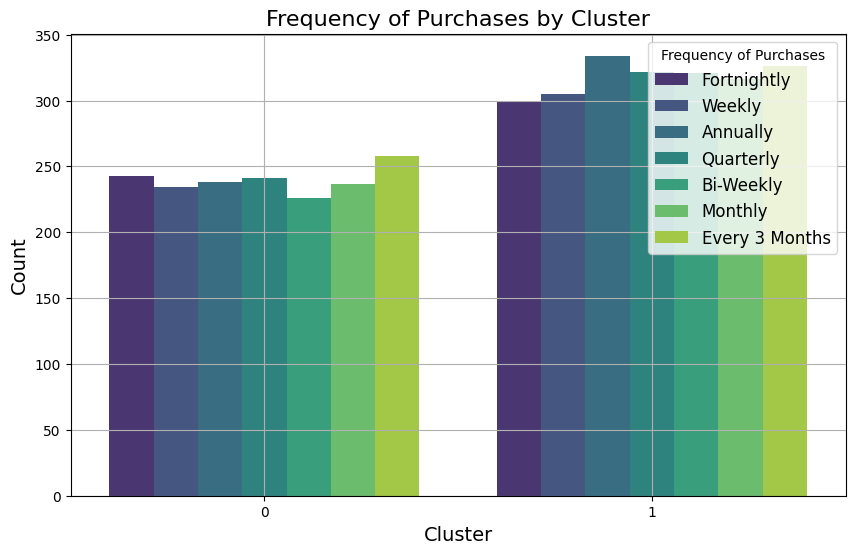

In [51]:
# Group data by cluster and summarize characteristics
cluster_summary = df.groupby('Cluster').agg({
    'Gender': lambda x: x.value_counts().index[0],  # Most common gender
    'Frequency of Purchases': lambda x: x.value_counts().index[0],  # Most common frequency
    'Item Purchased': lambda x: x.value_counts().index[0],  # Most common item
    'Season': lambda x: x.value_counts().index[0],  # Most common season
    'Subscription Status': lambda x: x.value_counts().index[0],  # Most common subscription
    'Payment Method': lambda x: x.value_counts().index[0],  # Most common payment method
    'Shipping Type': lambda x: x.value_counts().index[0],  # Most common shipping type
})

print("Cluster Characteristics Summary:")
print(cluster_summary)

# Optional: Numerical summaries
numerical_summary = df.groupby('Cluster').mean(numeric_only=True)
print("\nNumerical Feature Summary:")
print(numerical_summary)

# Example: Gender distribution by cluster
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Cluster', hue='Gender', palette='viridis')
plt.title("Gender Distribution by Cluster", fontsize=16)
plt.xlabel("Cluster", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.legend(title="Gender", fontsize=12)
plt.grid()
plt.show()

# Example: Frequency of Purchases distribution by cluster
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Cluster', hue='Frequency of Purchases', palette='viridis')
plt.title("Frequency of Purchases by Cluster", fontsize=16)
plt.xlabel("Cluster", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.legend(title="Frequency of Purchases", fontsize=12)
plt.grid()
plt.show()


### **Cluster Characteristics Summary**

#### **Cluster 0**:
1. **Gender**: Predominantly Male.
2. **Frequency of Purchases**: Customers in this cluster tend to shop **Every 3 Months**.
3. **Item Purchased**: The most commonly purchased item is **Pants**.
4. **Season**: Most purchases occur during the **Spring** season.
5. **Subscription Status**: Majority of customers are subscribed (**Yes**).
6. **Payment Method**: Predominantly use **Credit Card** for transactions.
7. **Shipping Type**: They prefer **Next Day Air** for shipping.

#### **Cluster 1**:
1. **Gender**: Predominantly Female.
2. **Frequency of Purchases**: Customers in this cluster shop **Annually**.
3. **Item Purchased**: The most commonly purchased item is **Blouse**.
4. **Season**: Most purchases occur during the **Fall** season.
5. **Subscription Status**: Majority are **not subscribed**.
6. **Payment Method**: Like Cluster 0, they also predominantly use **Credit Card**.
7. **Shipping Type**: They prefer **Free Shipping**.

---

### **Numerical Feature Summary**

#### **Cluster 0**:
1. **Purchase Amount (USD)**: 
   - Average purchase amount is **$59.28**, slightly lower than Cluster 1.
   - Indicates budget-conscious or smaller transactions.
   
2. **Review Rating**: 
   - Average review rating is **3.74**, which is consistent but slightly lower than Cluster 1.
   - Suggests satisfaction but possibly fewer standout experiences.

3. **Previous Purchases**:
   - Average number of previous purchases is **25.74**.
   - Indicates slightly more repeat customers compared to Cluster 1.

4. **Birth Year**:
   - Average birth year is **1979.86**, suggesting customers are around **45 years old** on average.

#### **Cluster 1**:
1. **Purchase Amount (USD)**:
   - Average purchase amount is **$60.13**, slightly higher than Cluster 0.
   - Indicates marginally higher spending.

2. **Review Rating**:
   - Average review rating is **3.76**, slightly better than Cluster 0.
   - Suggests higher customer satisfaction or better product alignment.

3. **Previous Purchases**:
   - Average number of previous purchases is **25.06**, slightly lower than Cluster 0.
   - Indicates fewer repeat customers compared to Cluster 0.

4. **Birth Year**:
   - Average birth year is **1979.99**, suggesting customers are also around **45 years old**.

---

### **Insights**

1. **Gender and Purchase Frequency**:
   - Cluster 0 is dominated by **male customers** who shop every **3 months**, possibly reflecting a more routine or periodic shopping pattern.
   - Cluster 1 is dominated by **female customers** who shop **annually**, potentially for special occasions or seasonal purchases.

2. **Item and Season**:
   - Cluster 0 prefers functional items like **Pants** during **Spring**.
   - Cluster 1 leans towards **Blouses**, aligning with **Fall fashion trends**.

3. **Subscription and Shipping Preferences**:
   - Cluster 0 shows higher engagement with **subscriptions** and values **fast shipping** (Next Day Air).
   - Cluster 1 prefers **no subscription** and values **cost savings** (Free Shipping).

4. **Spending and Satisfaction**:
   - Cluster 1 spends slightly more and leaves higher reviews, suggesting more satisfaction or premium purchases.
   - Cluster 0 may prioritize practicality or efficiency in their purchases.